# **TRABAJO PRÁCTICO 7 - SANTIAGO VOLIO**



# **EJERCICIO 1**

La expresión representa la cantidad total de galones de aceite que se han fugado del tanque durante los primeros diez minutos.

Es decir, mide toda la fuga acumulada desde el instante inicial hasta el minuto diez, tomando en cuenta que la rapidez puede cambiar con el tiempo.

# **EJERCICIO 2**

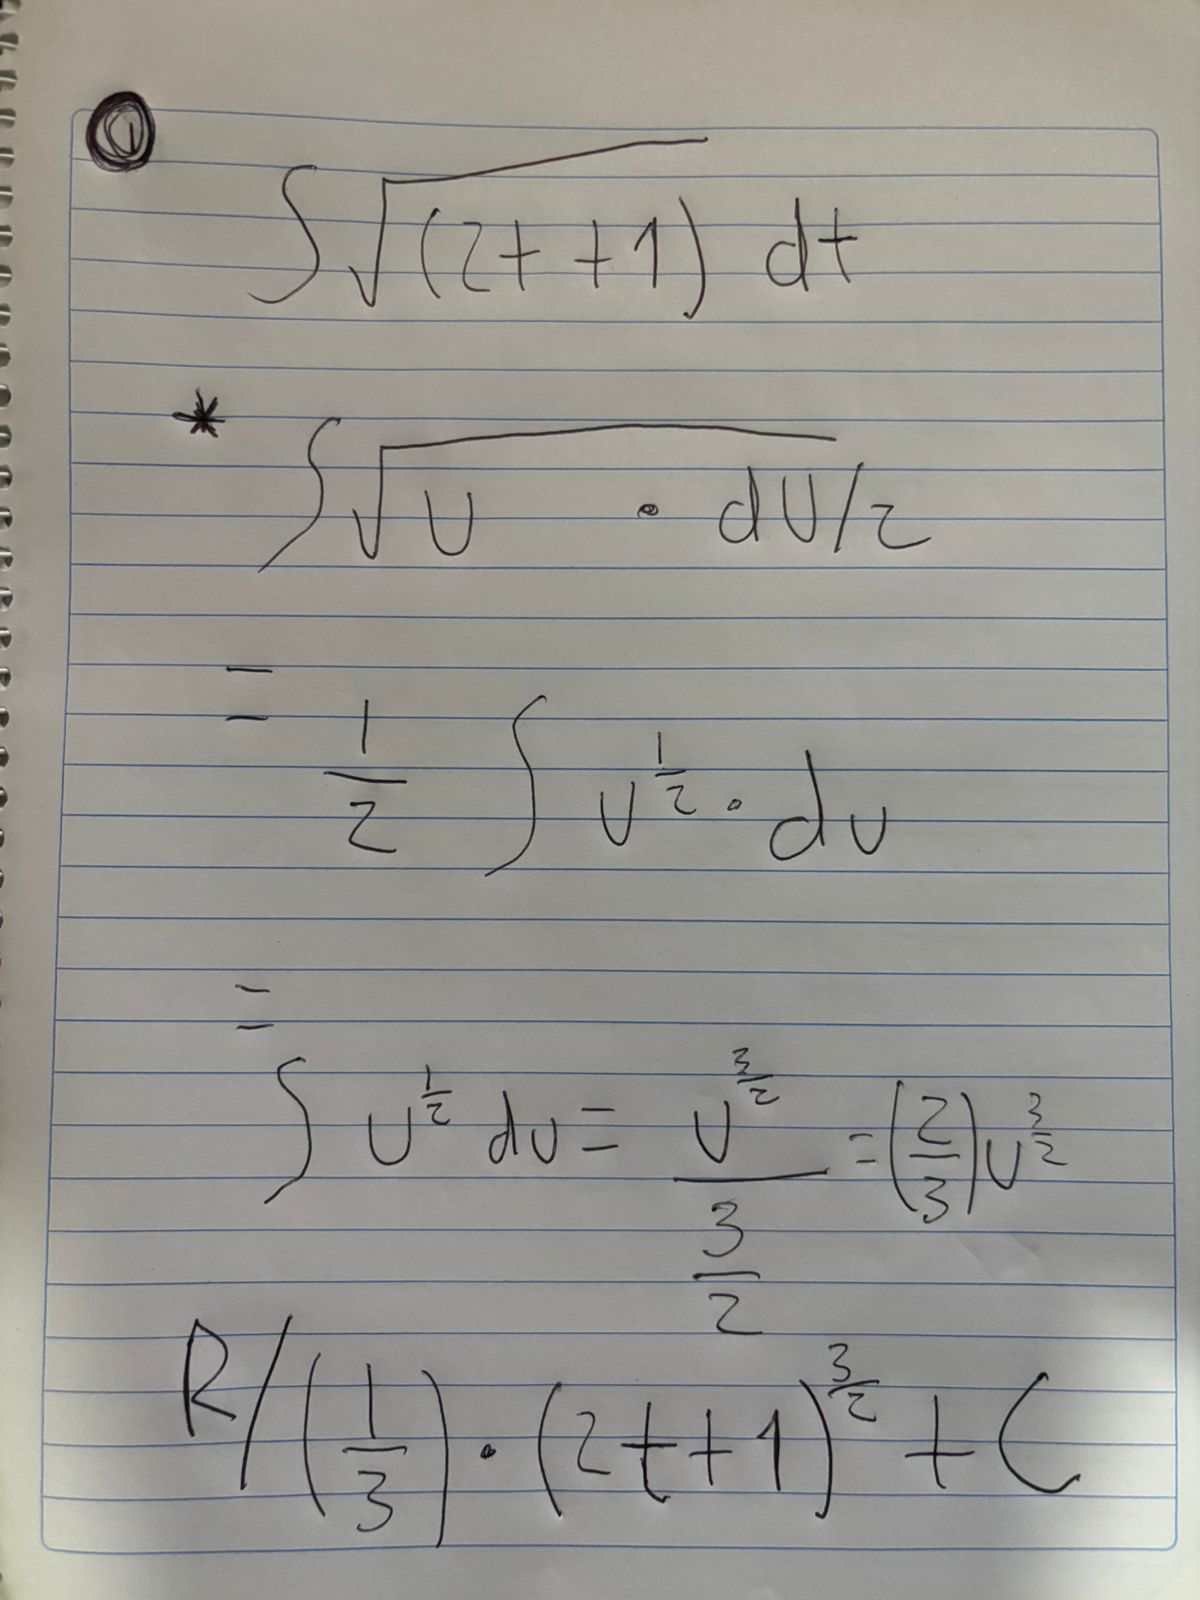

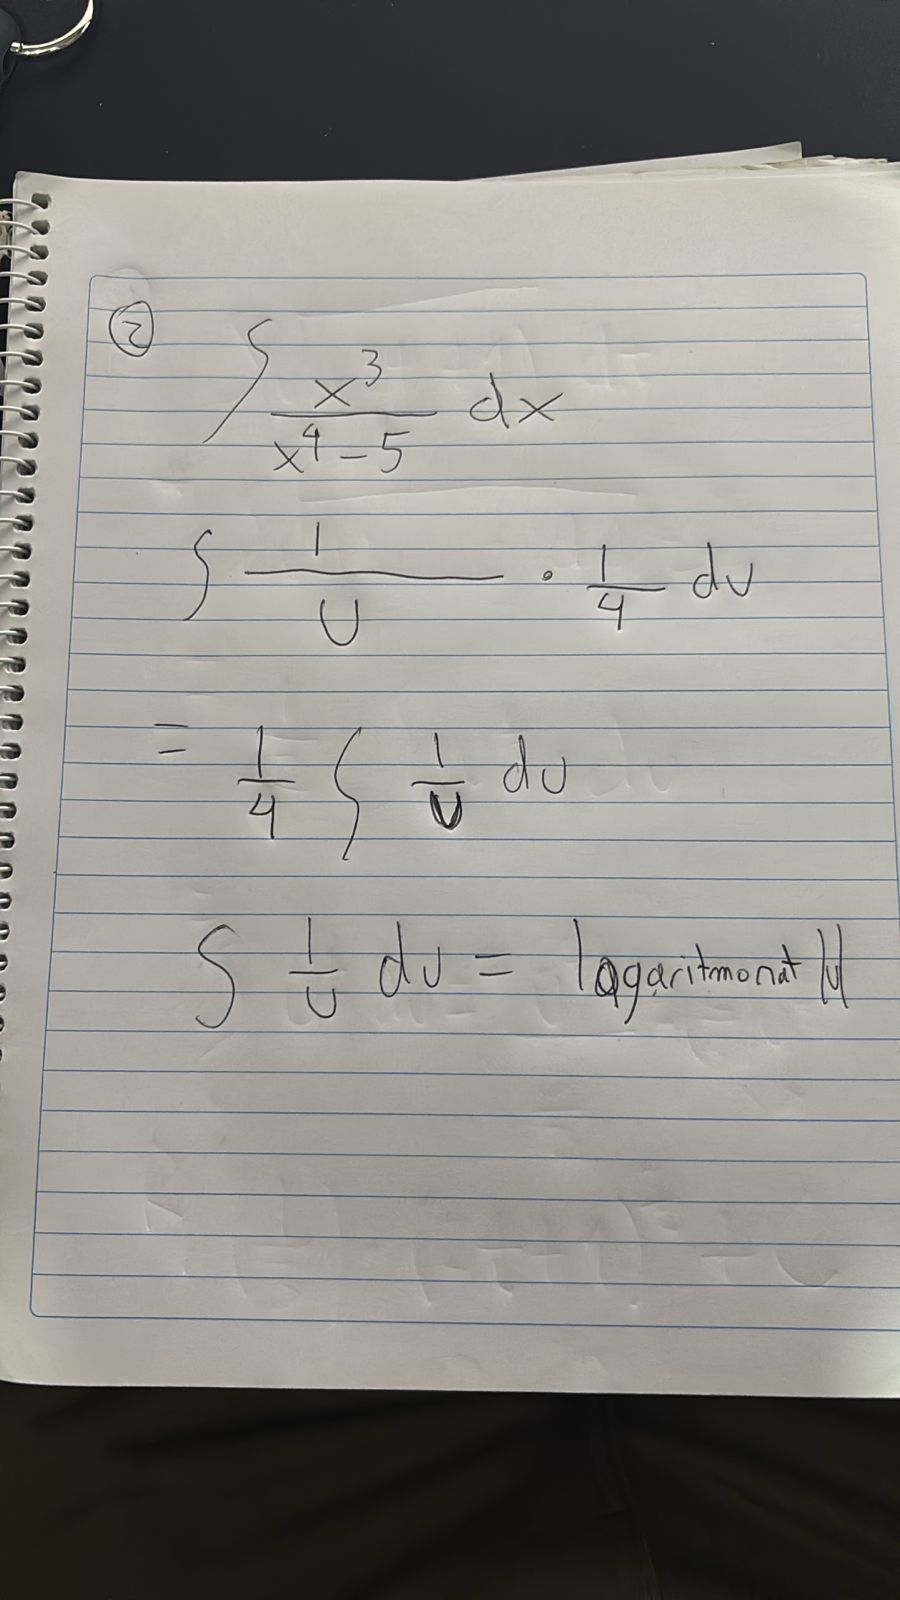

# **EJERCICIO 3**

In [ ]:
import sympy as sp

t = sp.Symbol('t')
P = 50 + 10*t   # potencia en kW

# POTENCIAS

potencia_inicio = P.subs(t, 0)
potencia_final = P.subs(t, 8)

# ENERGÍA CONSUMIDA

energia_total = sp.integrate(P, (t, 0, 8))   # en kWh

# -------- Prints para mostrar resultados --------
print("¿Cuál es la potencia al inicio del entrenamiento (t = 0)?")
print(potencia_inicio, "kW\n")

print("¿Cuál es la potencia al final del entrenamiento (t = 8)?")
print(potencia_final, "kW\n")

print("Energía total consumida durante las 8 horas:")
print(energia_total, "kWh")



¿Cuál es la potencia al inicio del entrenamiento (t = 0)?
50 kW

¿Cuál es la potencia al final del entrenamiento (t = 8)?
130 kW

Energía total consumida durante las 8 horas:
720 kWh


# **EJERCICIO 4**

In [ ]:
import sympy as sp
import numpy as np


x = sp.Symbol('x')
f = 6 - 0.5*x**2  # techo del túnel
g = 0.2*x**2      # piso del túnel

# Intersecciones
puntos = sp.solve(sp.Eq(f, g), x)

# Area del tunel
area_simbolica = sp.integrate(f - g, (x, puntos[0], puntos[1]))

# Area del valor
area_num = np.float64(float(area_simbolica.evalf()))


# Respuestas
print("Puntos de intersección entre el techo y el piso:")
print(" ")

print("Coordenadas de intersección (approx) ≈ ",
      [round(float(p.evalf()), 2) for p in puntos])
print("Coordenadas de intersección (exactas) : ",
      [float(p.evalf()) for p in puntos])   # redondeo abajo

print(" ")

print("Área total del túnel")
print(" ")
print("Area redondeada: ", round(area_num, 2), "m^2")   # redondeo
print("Área del túnel (exacta): ", area_num, "m^2")


print(" ")

print("Interpretación:")
print(" ")
print("El área representa la sección transversal interior del túnel,")
print("por lo tanto, el tamaño del espacio disponible para que pase el metro.")


Puntos de intersección entre el techo y el piso:
 
Coordenadas de intersección (approx) ≈  [-2.93, 2.93]
Coordenadas de intersección (exactas) :  [-2.9277002188455996, 2.9277002188455996]
 
Área total del túnel
 
Area redondeada:  23.42 m^2
Área del túnel (exacta):  23.4216017507648 m^2
 
Interpretación:
 
El área representa la sección transversal interior del túnel,
por lo tanto, el tamaño del espacio disponible para que pase el metro.


# **EJERCICIO 5**

Nivel de concentración al inicio (t = 10):
1210.0 células/mL
 
Nivel de concentración al final (t = 18):
1026.0 células/mL
 
Área (nivel de infección):
1877.33 células/mL · días
 


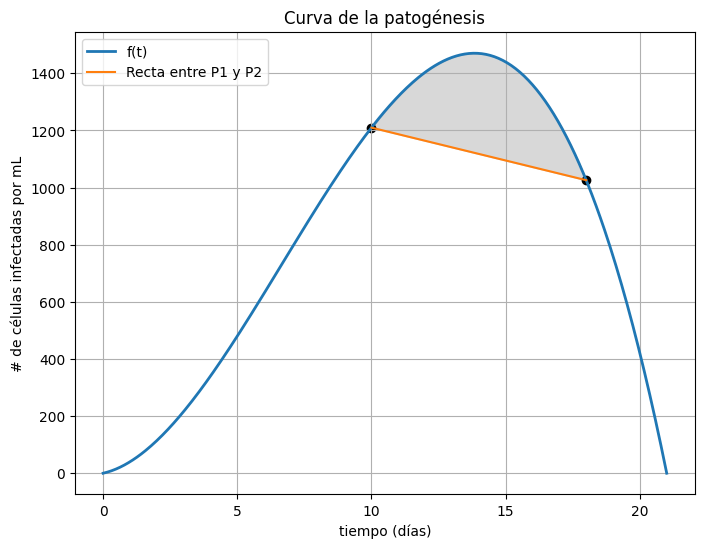

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


t = sp.Symbol('t')
f = -t * (t - 21) * (t + 1)

# Intervalo de infecciones
t1 = 10
t2 = 18

# Niveles de concentración

f_t1 = float(f.subs(t, t1))
f_t2 = float(f.subs(t, t2))
f_t1_r = round(f_t1, 2)
f_t2_r = round(f_t2, 2)

print("Nivel de concentración al inicio (t = 10):")
print(f_t1_r, "células/mL")
print(" ")

print("Nivel de concentración al final (t = 18):")
print(f_t2_r, "células/mL")
print(" ")

# Recta entre los 2 periodos
m = (f_t2 - f_t1) / (t2 - t1)
b = f_t1 - m * t1
recta = m * t + b

# Área de infección (en la gráfica)
area_simbolica = sp.integrate(f - recta, (t, t1, t2))
area_num = np.float64(float(area_simbolica.evalf()))
area_num_r = round(area_num, 2)

print("Área (nivel de infección):")
print(area_num_r, "células/mL · días")
print(" ")

# GRÁFICA (OPCIONAL)
t_vals = np.linspace(0, 21, 400)
f_vals = [float(f.subs(t, val)) for val in t_vals]
t_fill = np.linspace(t1, t2, 300)
f_fill = [float(f.subs(t, val)) for val in t_fill]
recta_fill = [m * val + b for val in t_fill]
plt.figure(figsize=(8, 6))
plt.plot(t_vals, f_vals, label="f(t)", linewidth=2)
plt.plot([t1, t2], [f_t1, f_t2], label="Recta entre P1 y P2")
plt.fill_between(t_fill, f_fill, recta_fill, alpha=0.3, color='gray')
plt.scatter([t1, t2], [f_t1, f_t2], color="black")
plt.title("Curva de la patogénesis")
plt.xlabel("tiempo (días)")
plt.ylabel("# de células infectadas por mL")
plt.grid(True)
plt.legend()
plt.show()
